<a href="https://colab.research.google.com/github/Mahendra-69/CSL701-CS09_Machine-Learning-Lab/blob/main/Expriments/ML_Experiment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Mahendra Raghunathram Choudhari | Roll_No:CS09

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving auto-mpg.csv to auto-mpg (3).csv


In [ ]:
df = pd.read_csv("auto-mpg.csv", na_values="?")

print("First 5 Rows:")
print(df.head())

First 5 Rows:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model year  origin                   car name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  


In [ ]:
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB
None

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [ ]:
# Select required columns
df = df[['horsepower', 'mpg']]

# Remove missing values
df = df.dropna()

print("Dataset Shape:", df.shape)

Dataset Shape: (392, 2)


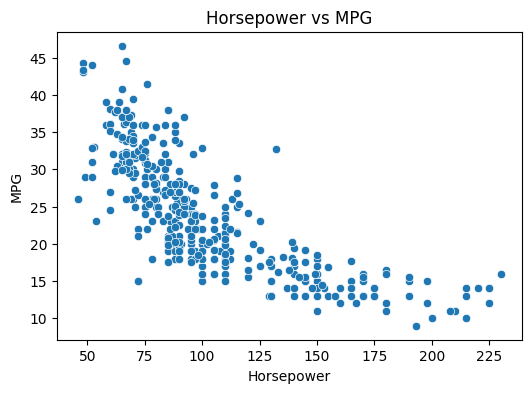

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='horsepower', y='mpg', data=df)
plt.title("Horsepower vs MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

In [ ]:
corr = df['horsepower'].corr(df['mpg'])

print("Correlation between Horsepower and MPG:", corr)

Correlation between Horsepower and MPG: -0.7784267838977756


In [ ]:
X = df['horsepower'].values
Y = df['mpg'].values

# Add bias term (intercept)
X_bias = np.column_stack((np.ones(len(X)), X))

In [ ]:
W = np.linalg.inv(X_bias.T @ X_bias) @ (X_bias.T @ Y)

print("Intercept (w0):", W[0])
print("Slope (w1):", W[1])

Intercept (w0): 39.93586102117056
Slope (w1): -0.1578447333536543


In [ ]:
Y_pred = X_bias @ W

print("First 10 Predicted Values:")
print(Y_pred[:10])

First 10 Predicted Values:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [ ]:
residuals = Y - Y_pred

print("First 10 Residuals:")
print(residuals[:10])

First 10 Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [ ]:
# Sum of Squared Errors
SSE = np.sum((Y - Y_pred) ** 2)

# Mean Squared Error
MSE = np.mean((Y - Y_pred) ** 2)

# Total Sum of Squares
SST = np.sum((Y - np.mean(Y)) ** 2)

# R² Score
R2 = 1 - (SSE / SST)

print("SSE :", SSE)
print("MSE :", MSE)
print("R² Score :", R2)

SSE : 9385.915871932419
MSE : 23.943662938603108
R² Score : 0.6059482578894348


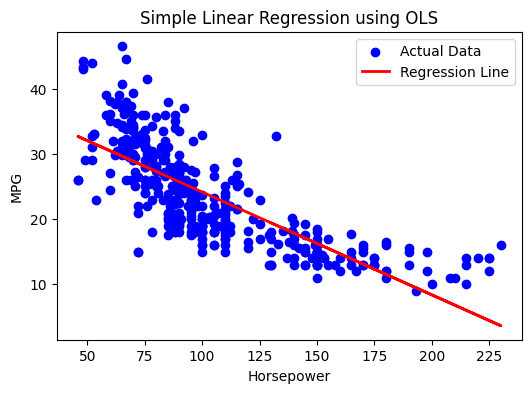

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression using OLS")

plt.legend()
plt.show()

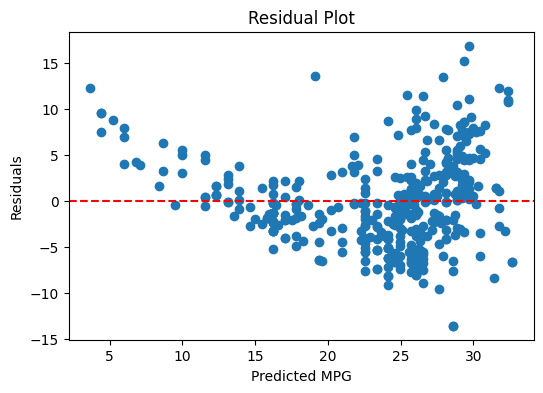

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(Y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
print("Regression Equation:")
print(f"MPG = {W[0]:.4f} + ({W[1]:.4f}) × Horsepower")

Regression Equation:
MPG = 39.9359 + (-0.1578) × Horsepower


In [ ]:
print("\nInterpretation:")
print("1. Horsepower and MPG have a negative correlation.")
print("2. As horsepower increases, fuel efficiency (MPG) decreases.")
print("3. The OLS model estimates the best-fit regression line.")
print("4. Lower SSE and MSE indicate better prediction accuracy.")
print("5. A higher R² value indicates a better fit of the model.")


Interpretation:
1. Horsepower and MPG have a negative correlation.
2. As horsepower increases, fuel efficiency (MPG) decreases.
3. The OLS model estimates the best-fit regression line.
4. Lower SSE and MSE indicate better prediction accuracy.
5. A higher R² value indicates a better fit of the model.
